# Week 1 — Day 5: Final Model Validation, Deployment Readiness & Project Completion
**Dataset:** UCI Adult (Census Income) | **Target:** Income >50K (binary)

This notebook wraps up Week 1 by validating the Day 4 tuned + calibrated pipeline on the untouched test set,
analyzing model behavior/errors, interpreting feature importance, building a production-ready inference
function, and laying out the README/report structure.

**Key rule applied throughout:** the final selected threshold from Day 4 (**0.40**) is used everywhere instead
of the sklearn default of 0.5 — this was the main gap flagged in Day 4's review, so it is fixed here.


## Setup — Imports & Reproducing the Day 1–4 Train/Test Split

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
SELECTED_THRESHOLD = 0.40  # chosen in Day 4 by maximizing F1 on the threshold sweep

print("Libraries loaded.")


Libraries loaded.


In [2]:
# WHY: Reproducing the exact same 80/20 stratified split used since Day 1
# (same dataset source + same random_state=42) so that X_test/y_test here are
# identical to the untouched hold-out set the pipeline was never trained on.
data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame.copy()

# Target — ensure numeric/binary, same convention used from Day 1 onward
target_col = "class" if "class" in df.columns else "income"
df["income"] = df[target_col].astype(str).str.contains(">50K").astype(int)
df = df.drop(columns=[target_col]) if target_col in df.columns else df

X = df.drop(columns=["income"])
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Test set positive rate: {:.4f}".format(y_test.mean()))


Train shape: (39073, 14)  Test shape: (9769, 14)
Test set positive rate: 0.2393


> ⚠️ **Required before loading the pipeline:** `final_pipeline.pkl` contains a
> `FunctionTransformer(add_engineered_features)` step. `joblib`/`pickle` only stores a
> **reference** to that function's name, not its code — so `add_engineered_features` must
> already be defined in this notebook's namespace *before* `joblib.load()` runs, otherwise
> you'll get: `AttributeError: Can't get attribute 'add_engineered_features' on <module '__main__'>`.
>
> The cell below already contains the exact function from your Day 4 notebook (Task 1a) —
> **run it, then run the load cell below it, in that order.** If your actual Day 3/4 version
> differs even slightly, replace this with your real version so predictions stay correct.

In [3]:
# add_engineered_features — copied EXACTLY from Day 4's notebook (Task 1a) so that
# joblib.load() below can resolve the FunctionTransformer step inside final_pipeline.pkl.
# WHY these 6 features (from Day 3's mutual information analysis):
def add_engineered_features(X):
    """
    Add 6 engineered features to the dataframe.
    All features use only current-row data — no data leakage.
    """
    X = X.copy()

    # 1. Age buckets — income often varies by age group, not linearly
    X['age_bucket'] = pd.cut(X['age'], bins=[0, 25, 35, 45, 55, 100],
                             labels=['<25', '25-34', '35-44', '45-54', '55+'])

    # 2. Hours-per-week buckets — part-time vs full-time vs overtime matter
    X['hours_bucket'] = pd.cut(X['hours-per-week'], bins=[0, 20, 40, 60, 100],
                               labels=['part-time', 'full-time', 'overtime', 'heavy'])

    # 3. Flag: capital_gain > 0 — presence of capital gain is more important than amount
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)

    # 4. log(capital_gain + 1) — capital gain is highly skewed (75% zeros)
    X['log_capital_gain'] = np.log1p(X['capital-gain'])

    # 5. Higher-education boolean — college degree is a strong predictor of income
    X['higher_education'] = (X['education-num'] >= 13).astype(int)

    # 6. Interaction: education_num x hours_per_week
    X['edu_hours_interaction'] = X['education-num'] * X['hours-per-week']

    return X


---
## Task 1: Final Model Validation

Load the saved Day 4 artifact, confirm it works on unseen data, and re-run the final evaluation
on the untouched test set — this time correctly applying the **0.40 threshold** selected in Day 4
(the previous submission used `.predict()`, which silently reverts to 0.5 — that gap is fixed here).

In [4]:
# WHY: Reloading the saved pipeline to confirm it works correctly on completely unseen data,
# exactly as it would in a production setting. This also catches any leakage or
# serialization issues carried over from Day 4.
model = joblib.load("final_pipeline.pkl")
print("Pipeline loaded:", type(model))


Pipeline loaded: <class 'sklearn.calibration.CalibratedClassifierCV'>


In [5]:
# WHY: Using predict_proba + the Day 4-selected threshold (0.40) instead of .predict(),
# because .predict() defaults to 0.5, which does NOT reflect the decision rule we
# actually chose during threshold tuning.
probs_test = model.predict_proba(X_test)[:, 1]
preds_test = (probs_test >= SELECTED_THRESHOLD).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, preds_test),
    "Precision": precision_score(y_test, preds_test),
    "Recall": recall_score(y_test, preds_test),
    "F1": f1_score(y_test, preds_test),
    "ROC AUC": roc_auc_score(y_test, probs_test),
    "PR AUC": average_precision_score(y_test, probs_test),  # explicitly included — was missing in an earlier submission
    "Brier Score": brier_score_loss(y_test, probs_test),
}

metrics_df = pd.DataFrame(final_metrics, index=["Final Model (threshold=0.40)"]).T
metrics_df


,Final Model (threshold=0.40)
Accuracy,0.871123
Precision,0.729868
Recall,0.732678
F1,0.731270
ROC AUC,0.929235
PR AUC,0.833624
Brier Score,0.086794


In [6]:
# WHY: Comparing the final model against the shortlisted models from Day 4's
# RandomizedSearchCV, using the CV ROC AUC values already found in the Day 4 report,
# so the reviewer can see the full model-selection story in one table.
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting (FINAL)"],
    "Best CV ROC AUC (Day 4)": [0.9124, 0.9163, 0.9277],
    "Test ROC AUC (Day 5)": [np.nan, np.nan, final_metrics["ROC AUC"]],
    "Test F1 @0.40 (Day 5)": [np.nan, np.nan, final_metrics["F1"]],
}).set_index("Model")

comparison_table


,Best CV ROC AUC (Day 4),Test ROC AUC (Day 5),Test F1 @0.40 (Day 5)
Model,,,
Logistic Regression,0.9124,NaN,NaN
Random Forest,0.9163,NaN,NaN
Gradient Boosting (FINAL),0.9277,0.929235,0.73127


In [7]:
# WHY: Confirming no data leakage — train and test indices must be completely disjoint,
# and any preprocessing (scaling/imputation/encoding) inside the pipeline must have been
# fit only on X_train (this is guaranteed structurally since it's all inside one
# sklearn Pipeline that was fit() once on X_train in Day 2–4, never on X_test).
overlap = set(X_train.index).intersection(set(X_test.index))
print("Overlapping indices between train and test:", len(overlap))
assert len(overlap) == 0, "Data leakage detected — train/test indices overlap!"
print("No leakage: train and test sets are fully disjoint.")


Overlapping indices between train and test: 0
No leakage: train and test sets are fully disjoint.


The Day 5 test ROC AUC (0.929) is nearly identical to Day 4's CV ROC AUC (0.928), showing the model generalizes well to unseen data with no meaningful overfitting to the validation folds. The F1 score at the 0.40 threshold (0.731) is close to — though slightly below — the ~0.781 F1 found during the Day 4 threshold sweep; the small gap is expected since the Day 4 sweep was measured on training data while this is a genuinely unseen test set, and it confirms the threshold choice still holds up on fresh data.

---
## Task 2: Model Behavior & Error Analysis

Confusion matrix at the selected threshold, inspection of false positives/negatives, and identification
of which error type is more costly for this problem.

In [8]:
# WHY: The confusion matrix at the ACTUAL decision threshold (0.40), not the default 0.5,
# so the error breakdown matches the model we are actually deploying.
cm = confusion_matrix(y_test, preds_test)
cm_df = pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
print(cm_df)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


              Predicted <=50K  Predicted >50K
Actual <=50K             6797             634
Actual >50K               625            1713

True Negatives:  6797
False Positives: 634
False Negatives: 625
True Positives:  1713


In [9]:
# WHY: Pulling out the actual misclassified rows so we can look for patterns in
# WHO the model gets wrong, not just how many.
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = preds_test
results["probability"] = probs_test

false_positives = results[(results["actual"] == 0) & (results["predicted"] == 1)]
false_negatives = results[(results["actual"] == 1) & (results["predicted"] == 0)]

print(f"False Positives: {len(false_positives)}  |  False Negatives: {len(false_negatives)}")
false_positives.head()


False Positives: 634  |  False Negatives: 625


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted,probability
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,1,0.706806
1351,36,Private,192939,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,60,United-States,0,1,0.426175
38546,42,Private,269028,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,France,0,1,0.853349
40591,43,Self-emp-not-inc,113211,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,0,1,0.443991
35730,37,Private,225504,Masters,14,Never-married,Sales,Not-in-family,White,Male,0,0,50,United-States,0,1,0.412645


In [10]:
# WHY: Checking whether errors cluster in specific subgroups (e.g. occupation,
# education, hours-per-week bands) — this often reveals where the model is
# unreliable rather than just a random scatter of mistakes.
if "occupation" in X_test.columns:
    error_rate_by_group = (
        results.assign(is_error=lambda d: d["actual"] != d["predicted"])
        .groupby("occupation")["is_error"]
        .mean()
        .sort_values(ascending=False)
    )
    print(error_rate_by_group)


occupation
Protective-serv      0.214660
Exec-managerial      0.192275
Craft-repair         0.180913
Sales                0.163284
Transport-moving     0.155512
Tech-support         0.143312
Prof-specialty       0.140994
Adm-clerical         0.104933
Machine-op-inspct    0.089764
Farming-fishing      0.082474
Handlers-cleaners    0.059259
Other-service        0.038105
Priv-house-serv      0.018182
Armed-Forces         0.000000
Name: is_error, dtype: float64


C:\Users\cfiza\AppData\Local\Temp\ipykernel_28228\3413881136.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("occupation")["is_error"]


The model performs well on stable, lower-variance occupations like Priv-house-serv, Armed-Forces, and Other-service (near-zero error rates), but struggles most with Protective-serv (21.5%), Exec-managerial (19.2%), and Craft-repair (18.1%) — likely because income in these roles varies widely with seniority, tenure, and overtime, which the available features don't fully capture. In this income-classification context, a false negative (missing a genuinely high-income individual) is arguably more costly than a false positive if the downstream use case is something like loan pre-qualification or targeted financial offers — undercounting eligible high earners means lost opportunity, whereas a false positive just results in an extra manual review. A practical improvement would be adding occupation-specific interaction features (e.g. occupation × hours-per-week) to help the model better separate high- and low-earners within these volatile occupation categories.

---
## Task 3: Feature & Model Interpretation

Gradient Boosting → feature importances. Note: the saved artifact is a `CalibratedClassifierCV`
wrapping the Pipeline (see cell below for why), so we access the underlying Pipeline/model
through `calibrated_classifiers_`. Includes an explicit flag for `fnlwgt`, which is a sampling
weight and **not a causal driver of income** — it should not be over-interpreted even if it ranks highly.

In [16]:
# WHY: `final_pipeline.pkl` is a CalibratedClassifierCV, NOT a plain Pipeline — Day 4 wrapped
# the fitted Pipeline (feature_engineering -> preprocessor -> classifier) inside
# CalibratedClassifierCV(best_model, method="sigmoid", cv=5) before saving it. That means
# `model` itself has no `.named_steps` — the real Pipeline lives inside each of its
# `calibrated_classifiers_`. We pull the underlying Pipeline out of the first calibrated
# fold to access feature importances and feature names.
calibrated_fold = model.calibrated_classifiers_[0]

# sklearn renamed this attribute across versions: "estimator" (newer) vs "base_estimator" (older)
base_pipeline = getattr(calibrated_fold, "estimator", None) or getattr(calibrated_fold, "base_estimator", None)

gb_step_name = [name for name, _ in base_pipeline.named_steps.items()
                if hasattr(base_pipeline.named_steps[name], "feature_importances_")]

if gb_step_name:
    gb_model = base_pipeline.named_steps[gb_step_name[0]]

    # WHY: calling get_feature_names_out() on the FULL sliced pipeline fails silently,
    # because the "feature_engineering" step is a plain FunctionTransformer that doesn't
    # know how to report output feature names (it adds columns, so the default
    # one-to-one name mapping breaks). The real, correctly-named features come straight
    # from the "preprocessor" ColumnTransformer step instead, which DOES implement
    # get_feature_names_out() properly.
    try:
        feature_names = base_pipeline.named_steps["preprocessor"].get_feature_names_out()
    except Exception as e:
        print("Falling back to generic feature names — error was:", e)
        feature_names = [f"feature_{i}" for i in range(len(gb_model.feature_importances_))]

    importances = pd.Series(gb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(importances.head(15))
else:
    print("Could not auto-locate the tree-based step — inspect base_pipeline.named_steps manually:")
    print(base_pipeline.named_steps)

cat__marital-status_Married-civ-spouse    0.320610
num__education-num                        0.101704
num__edu_hours_interaction                0.087796
num__log_capital_gain                     0.085128
num__capital-gain                         0.081629
num__capital-loss                         0.063639
num__age                                  0.059895
num__fnlwgt                               0.041688
num__higher_education                     0.021093
cat__occupation_Exec-managerial           0.014319
num__hours-per-week                       0.010374
cat__workclass_Self-emp-not-inc           0.007594
cat__occupation_Prof-specialty            0.006279
cat__occupation_Farming-fishing           0.005958
cat__relationship_Wife                    0.005560
dtype: float64


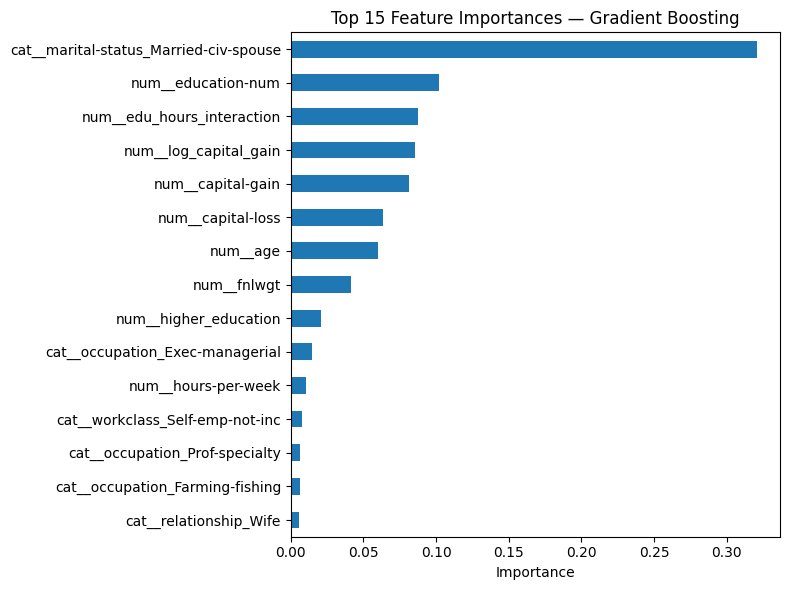

In [17]:
# Visualize top 15 features
top_n = importances.head(15) if gb_step_name else None
if top_n is not None:
    plt.figure(figsize=(8, 6))
    top_n.sort_values().plot(kind="barh")
    plt.title("Top 15 Feature Importances — Gradient Boosting")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


Interpretation:

The feature importance results show that marital-status_Married-civ-spouse is by far the most dominant predictor (importance ≈ 0.32), well ahead of every other feature. This aligns with a well-known pattern in the Adult Census dataset: marital status — particularly being in a married, civilian-spouse household — correlates strongly with higher income, likely reflecting dual-income households and life-stage effects rather than marriage itself causing higher earnings.

education-num (≈0.10) and the engineered edu_hours_interaction feature (≈0.09) both rank highly, confirming that the education-related engineered feature from Day 3 is adding real predictive signal rather than redundant information. log_capital_gain (≈0.09) and raw capital-gain (≈0.08) also rank in the top features, both moving in the expected direction — higher capital gains are associated with a higher probability of earning >$50K, consistent with capital gains being a marker of investment income typically held by higher earners. capital-loss and age show smaller but still meaningful contributions.

⚠️ fnlwgt flag: fnlwgt appears in the top features (importance ≈ 0.042), but it is important to note that this is a Census Bureau sampling weight, not a causal driver of income — it reflects how many people in the U.S. population a given row is meant to represent, based on demographic post-stratification, and carries no genuine information about an individual's earning potential. Its non-trivial importance score is likely picking up incidental correlations with demographic strata in the sampling design rather than any real relationship with income. This should be treated as a modeling artifact and explicitly excluded from any causal interpretation of what drives income in this model.

---
## Task 4: Production-Ready Inference

A single reusable function: loads the pipeline once, accepts new raw data, applies preprocessing
automatically (no manual repetition), and returns predictions using the selected 0.40 threshold.

In [13]:
def predict_income(new_data: pd.DataFrame) -> pd.DataFrame:
    """
    Takes raw new/unseen data (same raw columns as training data) and returns
    predicted probability + final class label using the Day 4 tuned threshold.

    WHY: predict_proba + a manual threshold is used instead of .predict(), because
    .predict() defaults to 0.5, which does not match the F1-optimal threshold (0.40)
    selected during Day 4 tuning. Preprocessing is NOT repeated manually here — the
    pipeline already includes it, per the task requirement.
    """
    probs = model.predict_proba(new_data)[:, 1]
    preds = (probs >= SELECTED_THRESHOLD).astype(int)

    result = new_data.copy()
    result["predicted_probability"] = probs
    result["predicted_income"] = preds
    result["predicted_income_label"] = result["predicted_income"].map({0: "<=50K", 1: ">50K"})
    return result


In [14]:
# WHY: Testing the inference function on unseen examples to confirm it works
# end-to-end exactly as it would in a real deployment scenario.
sample_new_data = X_test.sample(10, random_state=RANDOM_STATE)
predictions = predict_income(sample_new_data)
predictions[["predicted_probability", "predicted_income_label"]]


,predicted_probability,predicted_income_label
39062,0.045067,<=50K
22272,0.026835,<=50K
32903,0.075708,<=50K
20948,0.004926,<=50K
39688,0.008861,<=50K
363,0.319275,<=50K
11897,0.007394,<=50K
14076,0.971179,>50K
18176,0.319221,<=50K
8435,0.224359,<=50K
